In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [41]:
import warnings
warnings.filterwarnings('ignore')

In [42]:
df = pd.read_csv('//Users/mchowdhury/Downloads/Churn_Modelling 3.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [43]:
df1=df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df1

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [44]:
df1.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [45]:
df1.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

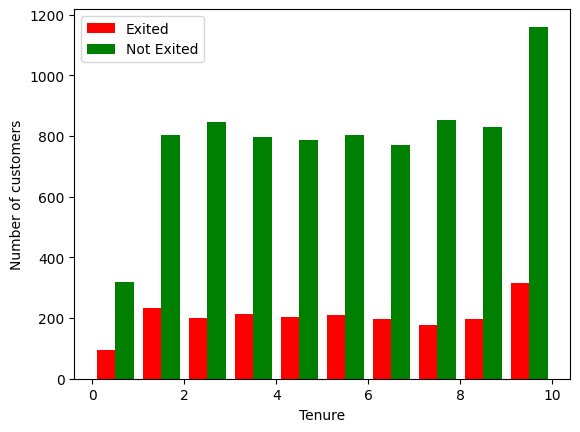

In [46]:
Tenure_exited_yes = df1.Tenure[df1.Exited == 1]
Tenure_exited_no = df1.Tenure[df1.Exited == 0]
plt.xlabel('Tenure')
plt.ylabel('Number of customers')
plt.hist([Tenure_exited_yes, Tenure_exited_no], color=['red', 'green'], label=['Exited', 'Not Exited'])
plt.legend()

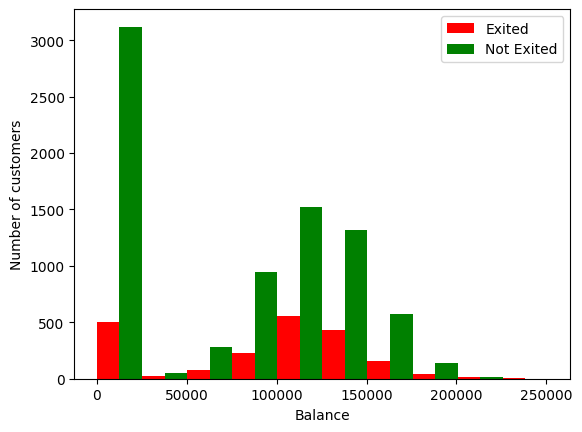

In [47]:
Balance_exited_yes = df1.Balance[df1.Exited == 1]
Balance_exited_no = df1.Balance[df1.Exited == 0]
plt.xlabel('Balance')
plt.ylabel('Number of customers')
plt.hist([Balance_exited_yes, Balance_exited_no], rwidth=5, color=['red', 'green'], label=['Exited', 'Not Exited'])
plt.legend()

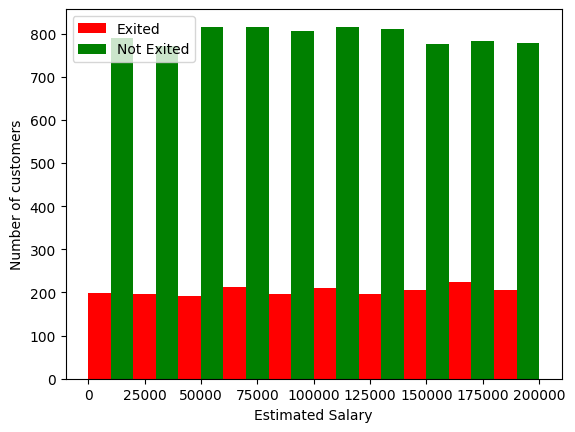

In [48]:
EstimatedSalary_exited_yes = df1.EstimatedSalary[df1.Exited == 1]
EstimatedSalary_exited_no = df1.EstimatedSalary[df1.Exited == 0]
plt.xlabel('Estimated Salary')
plt.ylabel('Number of customers')
plt.hist([EstimatedSalary_exited_yes, EstimatedSalary_exited_no], rwidth=5, color=['red', 'green'], label=['Exited', 'Not Exited'])
plt.legend()

In [49]:
df1['Gender']  =  df1['Gender'].replace({'Male': 0, 'Female': 1}, inplace=True,).astype(float)
df1['Geography'] = df1['Geography'].replace({'France': 0, 'Spain': 1, 'Germany': 2}, inplace=True,).astype(float)

In [50]:

df1.Gender.unique(), df1.Geography.unique()

(array([1., 0.]), array([0., 1., 2.]))

In [51]:
df1.dtypes

CreditScore          int64
Geography          float64
Gender             float64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [52]:
colmn_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df1[colmn_to_scale] = scaler.fit_transform(df1[colmn_to_scale])
df1

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.538,0.0,1.0,0.324324,0.2,0.000000,0.000000,1,1,0.506735,1
1,0.516,1.0,1.0,0.310811,0.1,0.334031,0.000000,0,1,0.562709,0
2,0.304,0.0,1.0,0.324324,0.8,0.636357,0.666667,1,0,0.569654,1
3,0.698,0.0,1.0,0.283784,0.1,0.000000,0.333333,0,0,0.469120,0
4,1.000,1.0,1.0,0.337838,0.2,0.500246,0.000000,1,1,0.395400,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,0.842,0.0,0.0,0.283784,0.5,0.000000,0.333333,1,0,0.481341,0
9996,0.332,0.0,0.0,0.229730,1.0,0.228657,0.000000,1,1,0.508490,0
9997,0.718,0.0,1.0,0.243243,0.7,0.000000,0.000000,0,1,0.210390,1
9998,0.844,2.0,0.0,0.324324,0.3,0.299226,0.333333,1,0,0.464429,1


In [53]:
x = df1.drop('Exited', axis=1)
y = df1.Exited
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=20)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [54]:
import numpy as np
x_test = np.array(x_test)
y_test = np.array(y_test)

In [55]:
model.fit(x_train, y_train)
accuracy  =  model.score(x_test, y_test)
accuracy

0.8216

In [56]:
len(x_train.columns)

10

With hidden layer

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
df1.dtypes

CreditScore        float64
Geography          float64
Gender             float64
Age                float64
Tenure             float64
Balance            float64
NumOfProducts      float64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [59]:
def ANN_model(x_train, y_train, weight):
    model1 = keras.Sequential([
        keras.layers.Dense(10, activation='relu'),
        keras.layers.Dense(5, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')])
    model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    if weight == -1:
        model1.fit(x_train, y_train, epochs=100)
    else:
        model1.fit(x_train, y_train, epochs=100, class_weight=weight)

    print(model1.evaluate(x_test, y_test))

    y_pred = model.predict(x_test)
    y_pred = np.round(y_pred)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    return y_pred


In [60]:
y_pred = ANN_model(x_train, y_train, -1)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 455us/step - accuracy: 0.7921 - loss: 0.5395
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.7921 - loss: 0.4935
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - accuracy: 0.7921 - loss: 0.4800
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.7921 - loss: 0.4699
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - accuracy: 0.7921 - loss: 0.4620
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - accuracy: 0.7921 - loss: 0.4550
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.7921 - loss: 0.4494
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - accuracy: 0.7921 - loss: 0.4440
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - accuracy: 0.7921 - loss: 0.4400
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.7921 - loss: 0.4354
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.7921 - loss: 0.4318
Epoch 12/100
235/23

In [61]:
df1.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Undersampling

In [62]:
count_class_0, count_class_1 = df1.Exited.value_counts()
df_class_0 = df1[df1['Exited'] == 0]
df_class_1 = df1[df1['Exited'] == 1]
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)
df_test_under.Exited.value_counts()

Exited
0    2037
1    2037
Name: count, dtype: int64

In [63]:
x = df_test_under.drop('Exited', axis=1)
y = df_test_under.Exited
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=20, stratify=y)
y_pred = ANN_model(x_train, y_train, -1)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - accuracy: 0.5375 - loss: 0.6919  
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - accuracy: 0.6196 - loss: 0.6655
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - accuracy: 0.6426 - loss: 0.6529
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - accuracy: 0.6543 - loss: 0.6419
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.6573 - loss: 0.6327
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.6655 - loss: 0.6243
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.6700 - loss: 0.6176
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.6750 - loss: 0.6104
Epoch 9/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.6822 - loss: 0.6045
Epoch 10/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6825 - loss: 0.5998
Epoch 11/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.6907 - loss: 0.5948
Epoch 12/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0

Oversampling

In [64]:
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)
df_test_over.Exited.value_counts()

Exited
0    7963
1    7963
Name: count, dtype: int64

In [65]:
x = df_test_over.drop('Exited', axis=1)
y = df_test_over.Exited
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=20, stratify=y)

In [66]:
y_pred = ANN_model(x_train, y_train, -1)

Epoch 1/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 426us/step - accuracy: 0.5840 - loss: 0.6741
Epoch 2/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.6534 - loss: 0.6324
Epoch 3/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.6774 - loss: 0.6053
Epoch 4/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.6894 - loss: 0.5898
Epoch 5/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.7027 - loss: 0.5744
Epoch 6/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.7151 - loss: 0.5605
Epoch 7/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.7289 - loss: 0.5464
Epoch 8/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step - accuracy: 0.7387 - loss: 0.5319
Epoch 9/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - accuracy: 0.7425 - loss: 0.5221
Epoch 10/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.7487 - loss: 0.5142
Epoch 11/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step - accuracy: 0.7495 - loss: 0.5081
Epoch 12/100
374/37

SMOTE

In [67]:
x - df1.drop('Exited', axis=1)
y - df1.Exited

0       0.0
0       0.0
0       0.0
0       0.0
0       0.0
       ... 
9998    0.0
9998    0.0
9998    0.0
9998    0.0
9999    0.0
Name: Exited, Length: 15966, dtype: float64

In [71]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')

x_sm, y_sm = smote.fit_resample(x, y)
y_sm.value_counts()

Exited
0    7963
1    7963
Name: count, dtype: int64

In [72]:
x_train, x_test, y_train, y_test = train_test_split(x_sm, y_sm, test_size=0.25, random_state=20, stratify=y_sm)
y_pred = ANN_model(x_train, y_train, -1)

Epoch 1/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 450us/step - accuracy: 0.6010 - loss: 0.6635
Epoch 2/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.6574 - loss: 0.6256
Epoch 3/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.6820 - loss: 0.6032
Epoch 4/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.6965 - loss: 0.5848
Epoch 5/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - accuracy: 0.7078 - loss: 0.5711
Epoch 6/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.7128 - loss: 0.5601
Epoch 7/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.7220 - loss: 0.5479
Epoch 8/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.7314 - loss: 0.5356
Epoch 9/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - accuracy: 0.7406 - loss: 0.5225
Epoch 10/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - accuracy: 0.7442 - loss: 0.5121
Epoch 11/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - accuracy: 0.7494 - loss: 0.5036
Epoch 12/100
374/37

Ensemble with undersampling

In [73]:
x = df1.drop('Exited', axis=1)
y = df1.Exited
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=20, stratify=y)

In [74]:
df2_class_0 = df1[df1['Exited'] == 0]
df2_class_1 = df1[df1['Exited'] == 1]

In [77]:
df1.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [75]:
def get_train_batch(df_majority,df_minority,start,end):
    df_train = pd.concat([df_majority[start:end], df_minority], axis=0)
    x_train = df_train.drop('Exited', axis=1)
    y_train = df_train.Exited
    return x_train, y_train

In [78]:
x_train, y_train = get_train_batch(df2_class_0,df2_class_1,0,2037)
y_pred1 = ANN_model(x_train, y_train, -1)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 535us/step - accuracy: 0.5862 - loss: 0.6830
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.6362 - loss: 0.6526
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.6603 - loss: 0.6341
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - accuracy: 0.6703 - loss: 0.6214
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - accuracy: 0.6824 - loss: 0.6066
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.6924 - loss: 0.5912
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - accuracy: 0.6996 - loss: 0.5767
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.7079 - loss: 0.5624
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - accuracy: 0.7194 - loss: 0.5495
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - accuracy: 0.7285 - loss: 0.5373
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - accuracy: 0.7381 - loss: 0.5272
Epoch 12/100
128/12

In [79]:
x_train, y_train = get_train_batch(df2_class_0,df2_class_1,2037,4074)
y_pred2 = ANN_model(x_train, y_train, -1)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.5326 - loss: 0.6905
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.5822 - loss: 0.6781
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.6168 - loss: 0.6633
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.6355 - loss: 0.6428
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.6556 - loss: 0.6285
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - accuracy: 0.6630 - loss: 0.6178
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - accuracy: 0.6743 - loss: 0.6099
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.6767 - loss: 0.6037
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.6809 - loss: 0.5983
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.6888 - loss: 0.5922
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.6846 - loss: 0.5891
Epoch 12/100
128/12

In [80]:
x_train, y_train = get_train_batch(df2_class_0,df2_class_1,4074,6111)
y_pred3 = ANN_model(x_train, y_train, -1)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - accuracy: 0.5459 - loss: 0.6894
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.6119 - loss: 0.6622
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - accuracy: 0.6316 - loss: 0.6427
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - accuracy: 0.6446 - loss: 0.6302
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.6534 - loss: 0.6209
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.6654 - loss: 0.6128
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.6703 - loss: 0.6054
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.6772 - loss: 0.5994
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.6807 - loss: 0.5935
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.6885 - loss: 0.5892
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - accuracy: 0.6902 - loss: 0.5856
Epoch 12/100
128/12

In [81]:
x_train ,y_train = get_train_batch(df2_class_0,df2_class_1,6111,8148)
y_pred4 = ANN_model(x_train, y_train, -1)

Epoch 1/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.4958 - loss: 0.6942
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.5338 - loss: 0.6738
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.6197 - loss: 0.6566
Epoch 4/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - accuracy: 0.6536 - loss: 0.6474
Epoch 5/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - accuracy: 0.6593 - loss: 0.6393
Epoch 6/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.6673 - loss: 0.6320
Epoch 7/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - accuracy: 0.6742 - loss: 0.6234
Epoch 8/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.6786 - loss: 0.6153
Epoch 9/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - accuracy: 0.6822 - loss: 0.6073
Epoch 10/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.6884 - loss: 0.6001
Epoch 11/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.6950 - loss: 0.5938
Epoch 12/100
122/12

In [82]:
len(y_pred1), len(y_pred2), len(y_pred3), len(y_pred4)

(2500, 2500, 2500, 2500)

In [84]:
y_pred_final = y_pred1.copy()
for i in range(len(y_pred1)):
    n_ones = y_pred1[i] + y_pred2[i] + y_pred3[i] + y_pred4[i]
    if n_ones >= 2:
        y_pred_final[i] = 1
    else:
        y_pred_final[i] = 0

In [90]:
classification_report(y_test, y_pred_final)

'              precision    recall  f1-score   support\n\n           0       0.83      0.97      0.89      1991\n           1       0.62      0.20      0.30       509\n\n    accuracy                           0.81      2500\n   macro avg       0.72      0.58      0.60      2500\nweighted avg       0.78      0.81      0.77      2500\n'